# Pipeline Stage-by-Stage Debugger

A debugging notebook where **each pipeline sub-step gets its own cell** so
we can inspect each intermediate step in isolation — before moving to the next cell. This helps us understand how the method works, how different steps in the process impact the results, and diagnose and resolve any issues.

Every cell calls `inspect()`, which:
1. Runs the same three formal QA checks (`all_nan`, `out_of_range`,
   `sporadic_nan_days`) from `saidownscale.qa_checks` — the same checks a
   `bcsd qa` run applies to a cached artifact.
2. Prints a PASS/FAIL verdict per check.
3. Plots a spatial map (`time=0`) and a domain-mean time series.
4. Registers the computed array in the `STEPS` dict so the cross-stage
   evolution plots at the bottom can iterate over every step.



In [1]:
import textwrap
import warnings

import matplotlib.pyplot as plt
import numpy as np
import rasterix  # noqa: F401  # registers .proj/.rio accessors
import xarray as xr
import xarray_regrid  # noqa: F401  # registers .regrid namespace

from saidownscale.bcsd_config import BCSDConfig, PipelineOptions
from saidownscale.downscaling_utils import (
    calculate_doy_means,
    downscale_from_coarse,
    interpolate_coarse_to_fine_grid,
    interpolate_fine_to_coarse_grid,
    retrend,
)
from saidownscale.pipeline import BCSDPipeline
from saidownscale.qa_checks import _STATUS_SYMBOL, run_artifact_checks
from saidownscale.validation import CheckStatus

warnings.filterwarnings("ignore", category=FutureWarning)


def _step_title(step: str, width: int = 16) -> str:
    """Wrap a snake_case step name to fit in a narrow subplot title."""
    return textwrap.fill(step.replace("_", " "), width=width)

## Config

**Edit only this cell** between debug runs. Set `SCENARIO = None` to debug
Stage 1 + Stage 2 only; set a scenario string to also exercise Stage 3.

`scratch_dir` and `output_dir` point to a local tmp directory so no debug
writes touch the real S3 cache.


In [44]:
# ── Edit these values ──────────────────────────────────────────────────────────
GCM = "CESM2-WACCM6"
VARIABLE = "rsds"
ENSEMBLE_MEMBER = "001"  # CESM2-WACCM6 SSP245/G6-1.5K uses numeric IDs; "001" → hist r1i1p1f1
SCENARIO = "SSP245"  # None → Stage 1+2 only; set e.g. "SSP245" / "G6-1.5K" to also exercise Stage 3

# Southern Africa including high spot in Angola.
# (lat_min, lat_max, lon_min, lon_max)
SUBSET_BOUNDS = (33, 45, 108, 123)

# ──────────────────────────────────────────────────────────────────────────────

config = BCSDConfig(
    gcm=GCM,
    variable=VARIABLE,
    ensemble_member=ENSEMBLE_MEMBER,
    scenario=SCENARIO,
    downscaling_method="QDMSD",
    # predict_period_start must equal the scenario data start (2015 for SSP245)
    # so stitch_historical_scenario produces a gap-free 1978–end timeseries.
    predict_period_start=2015 if SCENARIO else None,
    predict_period_end=2060 if SCENARIO else None,
    subset_bounds=SUBSET_BOUNDS,
)
options = PipelineOptions(
    scratch_dir="/tmp/bcsd-debug/scratch/",  # local — never touches S3
    output_dir="/tmp/bcsd-debug/output/",
    branch="debug",
    environment="debug",
)
pipeline = BCSDPipeline(config, options)
print(f"Run: {config.run_id}")
print(f"Subset bounds: {config.subset_bounds}")
print(f"Scenario: {config.scenario!r}")
print(f"Predict period: {config.predict_period_start}–{config.predict_period_end}")

Run: CESM2-WACCM_rsds_001_SSP245_subset
Subset bounds: (33.0, 45.0, 108.0, 123.0)
Scenario: 'SSP245'
Predict period: 2015–2060


## Inspection helper

`inspect(da, stage)` is called after every sub-step. It:
- `.compute()`s the DataArray (fine for the small subset region)
- Runs `run_artifact_checks()` (skipped for arrays with a `dayofyear` dim
  instead of a `time` dim, since those lack the time axis the checks need)
- Prints a PASS/FAIL line per check with detail for any non-PASS result
- Plots spatial map + domain-mean series
- Registers `da` in `STEPS` and its NaN fraction in `STEP_NAN_FRACTIONS`


In [45]:
STEPS: dict[str, xr.DataArray] = {}  # ordered; keys = step labels
STEP_NAN_FRACTIONS: dict[str, float] = {}  # per-step nan_fraction for bar chart


def inspect(
    da: xr.DataArray,
    stage: str,
    *,
    skip_qa: bool = False,
) -> xr.DataArray:
    """Compute, QA-check, plot, and register a pipeline intermediate."""
    print(f"\n{'=' * 60}")
    print(f"  {stage}")
    print(f"{'=' * 60}")

    da = da.compute()
    STEPS[stage] = da

    has_time = "time" in da.dims
    has_doy = "dayofyear" in da.dims

    # ── QA checks ─────────────────────────────────────────────────────────────
    if not skip_qa and has_time:
        results = run_artifact_checks(
            da,
            gcm=config.gcm,
            variable=config.variable,
            ensemble_member=config.ensemble_member,
            scenario=config.scenario,
            stage=stage,
        )
        STEP_NAN_FRACTIONS[stage] = results["all_nan"].nan_fraction
        for check_name, result in results.items():
            sym = _STATUS_SYMBOL[result.status]
            line = f"  {sym} {check_name}: {result.status.upper()}"
            if result.message:
                line += f" — {result.message}"
            print(line)
            if result.status not in (CheckStatus.PASS, CheckStatus.SKIP) and result.detail:
                for k, v in result.detail.items():
                    print(f"        {k}: {v}")
    elif has_doy:
        print("  (QA checks skipped — dayofyear dimension, no time axis)")
    else:
        print("  (QA checks skipped)")

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"  shape: {dict(da.sizes)}")
    if has_time or has_doy:
        nan_frac = float(np.isnan(da.values).mean())
        print(f"  NaN:   {nan_frac:.4f} ({nan_frac * 100:.2f}%)")

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(stage, fontsize=12, fontweight="bold")
    try:
        if has_time:
            da.isel(time=0).plot(ax=axes[0], add_colorbar=True)
            axes[0].set_title("time=0 (spatial map)")
            da.mean(["lat", "lon"]).plot(ax=axes[1])
            axes[1].set_title("domain-mean time series")
        elif has_doy:
            da.isel(dayofyear=0).plot(ax=axes[0], add_colorbar=True)
            axes[0].set_title("dayofyear=0 (spatial map)")
            da.mean(["lat", "lon"]).plot(ax=axes[1])
            axes[1].set_title("domain-mean DOY series")
        else:
            for ax in axes:
                ax.text(0.5, 0.5, "no time/dayofyear dim", transform=ax.transAxes, ha="center")
    except Exception as exc:
        for ax in axes:
            ax.text(
                0.5,
                0.5,
                f"plot error:\n{exc}",
                transform=ax.transAxes,
                ha="center",
                fontsize=8,
                wrap=True,
            )
    plt.tight_layout()
    plt.show()
    return da

## ERA5-relative exceedance helpers

Adapted from `synced/notebooks/check_reasonable_ranges.ipynb`. Unlike the
global physical-bounds check in `qa_checks.py`, these compare the downscaled
output against ERA5's **per-pixel** historical min/max — so a value that is
physically plausible globally but implausible at that specific location is
still flagged.

`obs_fine_s2` / `obs_fine_s3` (already in memory) serve as the ERA5
reference, so no extra S3 reads are needed.


In [46]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    _HAS_CARTOPY = True
except ImportError:
    _HAS_CARTOPY = False

_MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Grey for zero exceedances; continuous Reds for nonzero — makes clean regions
# immediately obvious without needing a separate mask plot.
_EXCEEDANCE_CMAP = plt.cm.Reds.copy()
_EXCEEDANCE_CMAP.set_under("lightgrey")


def _era5_threshold(obs_fine: xr.DataArray, direction: str, period: str) -> xr.DataArray:
    """Per-pixel ERA5 min/max from obs_fine already in memory.

    Parameters
    ----------
    obs_fine : already-computed fine-grid ERA5 DataArray
    direction : "gt" → max threshold; "lt" → min threshold
    period    : "annual" or "monthly"
    """
    fn = "max" if direction == "gt" else "min"
    if period == "annual":
        return getattr(obs_fine, fn)("time").compute()
    return getattr(obs_fine.groupby("time.month"), fn)("time").compute()


def _count_exceedances(
    da: xr.DataArray,
    threshold: xr.DataArray,
    direction: str,
    period: str,
) -> xr.DataArray:
    """Number of time steps per pixel that exceed the given threshold."""
    if period == "annual":
        mask = da > threshold if direction == "gt" else da < threshold
        return mask.sum("time").compute()
    counts = []
    for m, group in da.groupby("time.month"):
        exceeded = (
            group > threshold.sel(month=m) if direction == "gt" else group < threshold.sel(month=m)
        )
        counts.append(exceeded.sum("time").expand_dims(month=[m]))
    return xr.concat(counts, dim="month").compute()


def _plot_map(da, ax, title, **kw):
    """Single-panel map with optional cartopy coastlines."""
    proj_kw = {"transform": ccrs.PlateCarree()} if _HAS_CARTOPY else {}
    da.plot(ax=ax, **kw, **proj_kw)
    if _HAS_CARTOPY:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_title(title, fontsize=9)


def plot_time_extremes(da: xr.DataArray, label: str) -> None:
    """2×2 grid: time-min and time-max with default and robust color scaling."""
    proj = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), subplot_kw=proj)
    fig.suptitle(f"{label} — time extremes", fontweight="bold")
    _plot_map(da.min("time"), axes[0, 0], "time min")
    _plot_map(da.max("time"), axes[0, 1], "time max")
    _plot_map(da.min("time"), axes[1, 0], "time min (robust)", robust=True)
    _plot_map(da.max("time"), axes[1, 1], "time max (robust)", robust=True)
    plt.tight_layout()
    plt.show()


def check_era5_exceedances(
    da: xr.DataArray,
    obs_fine: xr.DataArray,
    label: str,
    period: str = "annual",
) -> None:
    """Flag pixels where da ever exceeds ERA5's per-pixel historical min/max.

    Prints pixel counts and plots exceedance maps (grey = clean, Reds = flagged).
    Set period="monthly" for a 3×4 faceted map — slower but more granular.
    """
    print(f"\n── ERA5-relative exceedance: {label} ({period}) ──")
    n_pixels = int(da.isel(time=0).size)

    for direction, label_suffix in [("gt", "days > ERA5 max"), ("lt", "days < ERA5 min")]:
        thresh = _era5_threshold(obs_fine, direction, period)
        count = _count_exceedances(da, thresh, direction, period)

        n_flagged = int((count > 0).sum().values)
        pct = n_flagged / n_pixels
        sym = "✗" if n_flagged > 0 else "✓"
        print(f"  {sym} {label_suffix}: {n_flagged}/{n_pixels} pixels flagged ({pct:.1%})")

        proj = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
        if period == "annual":
            fig, ax = plt.subplots(figsize=(8, 5), subplot_kw=proj)
            _plot_map(count, ax, f"{label}\n{label_suffix}", cmap=_EXCEEDANCE_CMAP, vmin=0.5)
            plt.tight_layout()
            plt.show()
        else:
            fig, axes = plt.subplots(3, 4, figsize=(20, 10), subplot_kw=proj)
            fig.suptitle(f"{label}\n{label_suffix}", fontsize=11)
            for i, ax in enumerate(axes.flat):
                _plot_map(
                    count.sel(month=i + 1),
                    ax,
                    _MONTH_NAMES[i],
                    cmap=_EXCEEDANCE_CMAP,
                    vmin=0.5,
                )
            plt.tight_layout()
            plt.show()

## Stage 1 — `prepare_observations`

Replicates the internals of `BCSDPipeline.prepare_observations` step by step. The final cell writes the result to the debug cache so Stage 2's `_load_gcm_obs()` can find it.


In [47]:
%%time
# ── Write to debug cache so Stage 2 _load_gcm_obs() can find obs_regridded ───
# This is equivalent to running prepare_observations() but on the debug branch.
# force=True overwrites any previous debug-branch artifact.
print("Writing obs_coarse to debug cache via prepare_observations(force=True) ...")
prepare_obs_path = pipeline.prepare_observations(force=True)
print(f"  → {prepare_obs_path}")

Writing obs_coarse to debug cache via prepare_observations(force=True) ...


  2026-09-04T04:57:40.458560Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324

  2026-09-04T04:57:40.776766Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324



  → /tmp/bcsd-debug/scratch/debug/CESM2-WACCM-ERA5-lat33.0to45.0_lon108.0to123.0.icechunk
CPU times: user 2min 54s, sys: 1min 16s, total: 4min 10s
Wall time: 1min 2s


## Stage 2 — `fit_historical` (debiasing + spatial downscaling)


  2026-09-04T04:58:42.515203Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324

  2026-09-04T04:58:42.516152Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324




  obs_coarse
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 13, 'lon': 12}
  NaN:   0.0000 (0.00%)


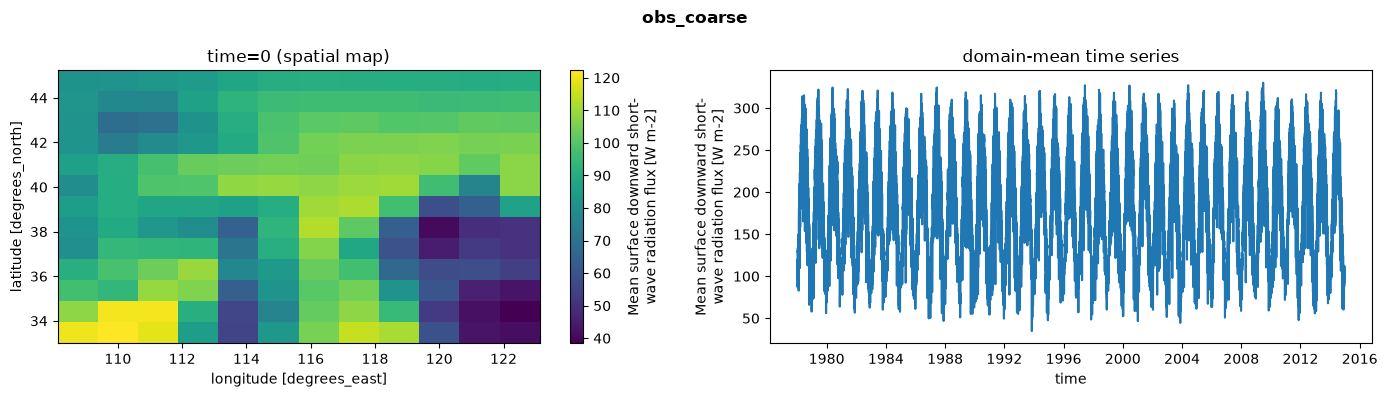


  obs_fine_s2
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 49, 'lon': 61}
  NaN:   0.0000 (0.00%)


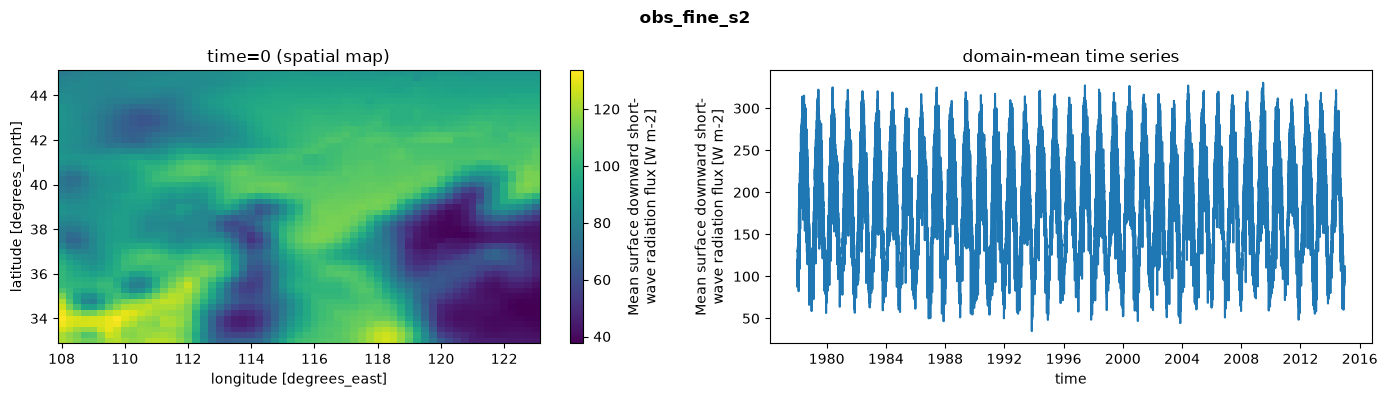


  model_hist
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 13, 'lon': 12}
  NaN:   0.0000 (0.00%)


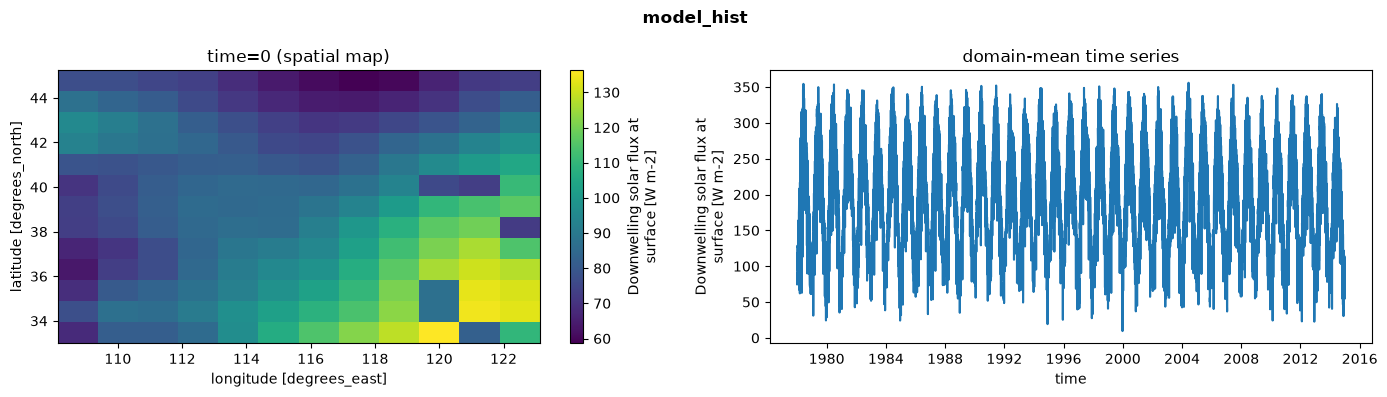

CPU times: user 1min 38s, sys: 41.5 s, total: 2min 20s
Wall time: 32.2 s


In [48]:
%%time
# ── _load_gcm_obs: reload from debug cache + load obs_fine, model_hist ────────
obs_coarse, obs_fine_s2, model_hist = pipeline._load_gcm_obs()
obs_coarse = inspect(obs_coarse, "obs_coarse")
obs_fine_s2 = inspect(obs_fine_s2, "obs_fine_s2")
model_hist = inspect(model_hist, "model_hist")


  debiased_coarse
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 13, 'lon': 12}
  NaN:   0.0000 (0.00%)


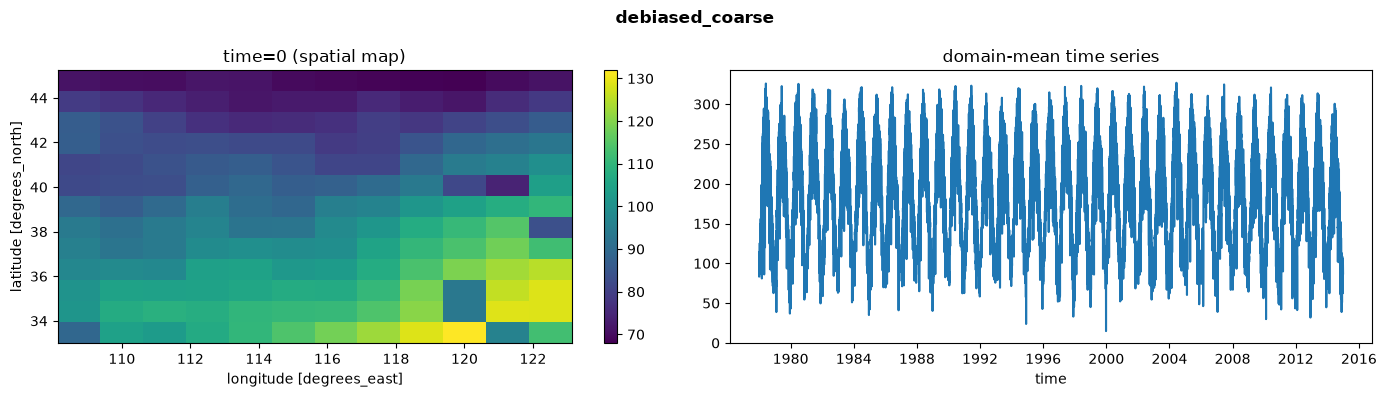

CPU times: user 249 ms, sys: 2.58 s, total: 2.83 s
Wall time: 3.21 s


In [49]:
%%time
# ── _apply_bias_correction: ibicus QuantileMapping on historical period ────────
# It calls .values / .load() internally so it is always eager; runtime ~ 1–5 min
# on the South Africa subset.
debiased_coarse = pipeline._apply_bias_correction(obs_coarse, model_hist)
debiased_coarse = inspect(debiased_coarse, "debiased_coarse")

### Spatial disaggregation sub-steps (Stage 2)

The single `_apply_spatial_downscaling()` call is expanded into five named
intermediates (Cells A–E) plus a consistency check (Cell F), so each step
can be inspected independently. These mirror the internals of
`downscale_from_coarse()` exactly.

> **Cell A** and **Cell B** compute the obs climatology, which is
> scenario-independent. The arrays will be reused in Stage 3 (starting from
> Cell C) so those cells do not need to rerun them.



  obs_fine_doy_means
  (QA checks skipped — dayofyear dimension, no time axis)
  shape: {'dayofyear': 366, 'lat': 49, 'lon': 61}
  NaN:   0.0000 (0.00%)


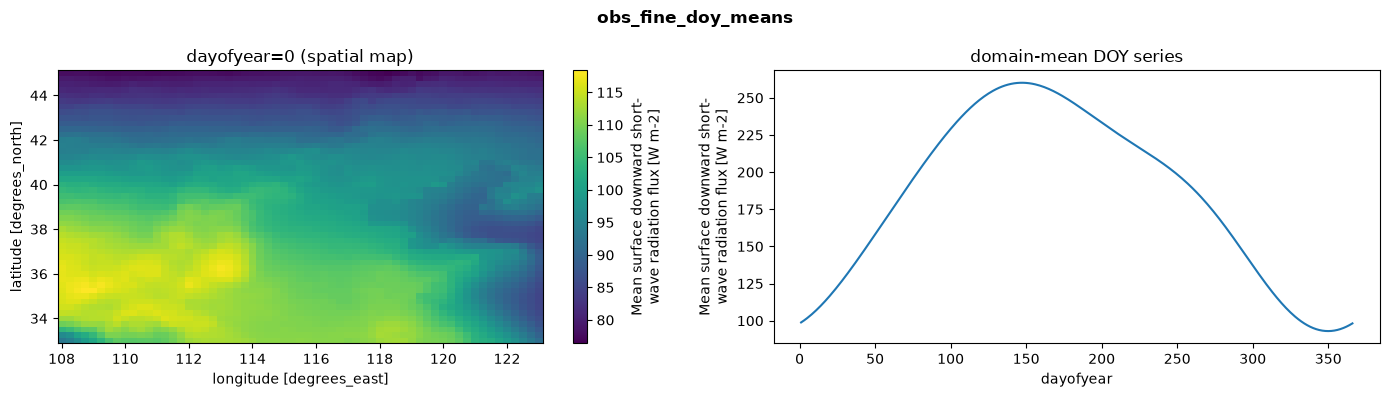

CPU times: user 395 ms, sys: 14.1 ms, total: 409 ms
Wall time: 304 ms


In [50]:
%%time
# ── Cell A: fine-grid day-of-year climatology ──────────────────────────────────
# Uses the downscaling_clim_method from config (typically "fft" for most vars).
# allow_negative_values=False mirrors production (_apply_spatial_downscaling):
# FFT smoothing can push a near-zero climatology below 0 for strictly-positive
# variables (pr, rsds), so those artifacts are clamped to 0 here.
obs_fine_doy_means = calculate_doy_means(
    obs_fine_s2,
    clim_method=config.variable_config.disaggregation_clim_method,
    allow_negative_values=False,
)
obs_fine_doy_means = inspect(obs_fine_doy_means, "obs_fine_doy_means")

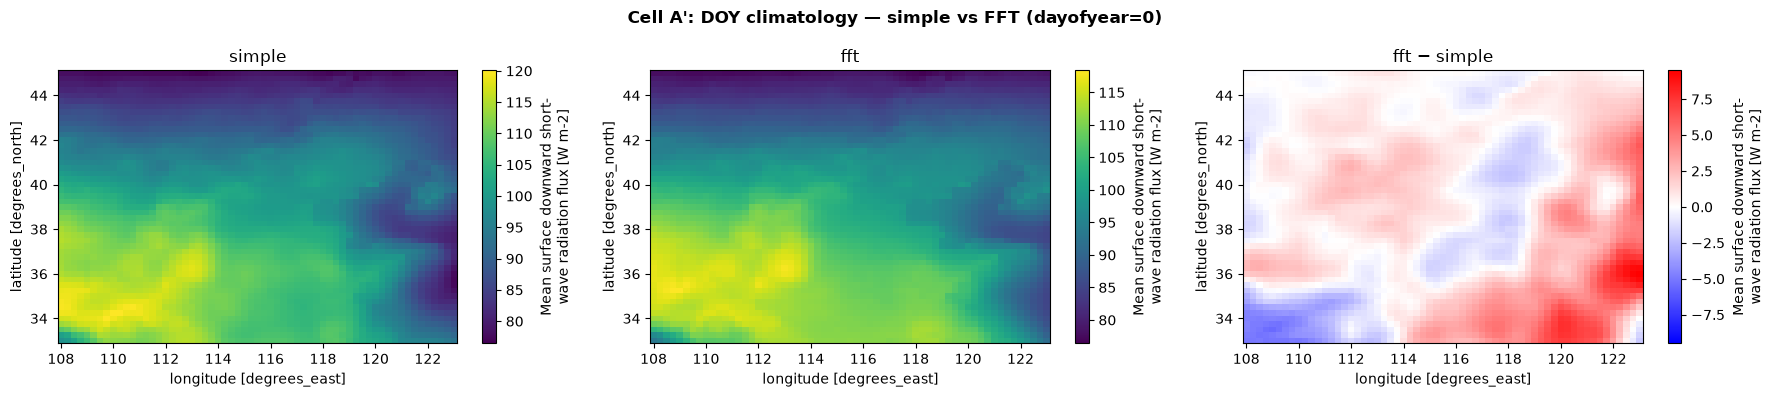

CPU times: user 603 ms, sys: 7.42 ms, total: 610 ms
Wall time: 423 ms


In [51]:
%%time
# ── Cell A': FFT vs simple climatology comparison ─────────────────────────────
# Three-panel map: simple | fft | diff (bwr, center=0) for dayofyear=0.
# Reveals FFT-smoothing artifacts found in prior QA notebooks. Uses the raw fft
# (allow_negative_values default True) on purpose, so any sub-zero artifacts that
# Cell A clamps to 0 for strictly-positive variables stay visible here.
obs_fine_doy_means_simple = calculate_doy_means(obs_fine_s2, clim_method="simple")
obs_fine_doy_means_fft = calculate_doy_means(obs_fine_s2, clim_method="fft")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Cell A': DOY climatology — simple vs FFT (dayofyear=0)", fontweight="bold")
kw = dict(add_colorbar=True)
obs_fine_doy_means_simple.isel(dayofyear=0).plot(ax=axes[0], **kw)
axes[0].set_title("simple")
obs_fine_doy_means_fft.isel(dayofyear=0).plot(ax=axes[1], **kw)
axes[1].set_title("fft")
diff = (obs_fine_doy_means_fft - obs_fine_doy_means_simple).isel(dayofyear=0)
diff.plot(ax=axes[2], cmap="bwr", center=0, **kw)
axes[2].set_title("fft − simple")
plt.tight_layout()
plt.show()


  obs_coarse_doy_means
  (QA checks skipped — dayofyear dimension, no time axis)
  shape: {'dayofyear': 366, 'lat': 13, 'lon': 12}
  NaN:   0.0000 (0.00%)


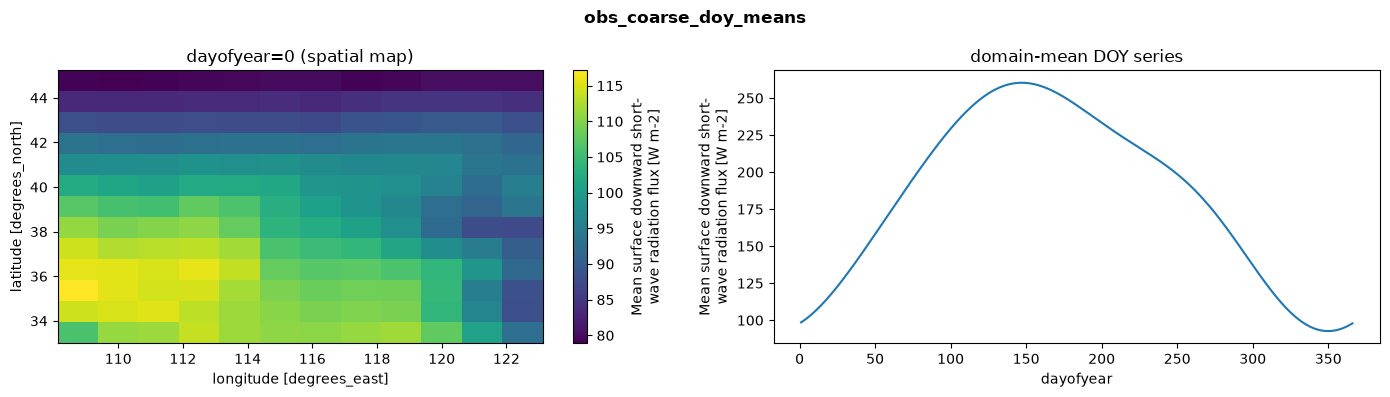

In [52]:
# ── Cell B: coarsen DOY climatology to GCM grid ───────────────────────────────
obs_coarse_doy_means = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine_doy_means, da_coarse_grid=obs_coarse
)
obs_coarse_doy_means = inspect(obs_coarse_doy_means, "obs_coarse_doy_means")


  residuals_coarse
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 13, 'lon': 12}
  NaN:   0.0000 (0.00%)


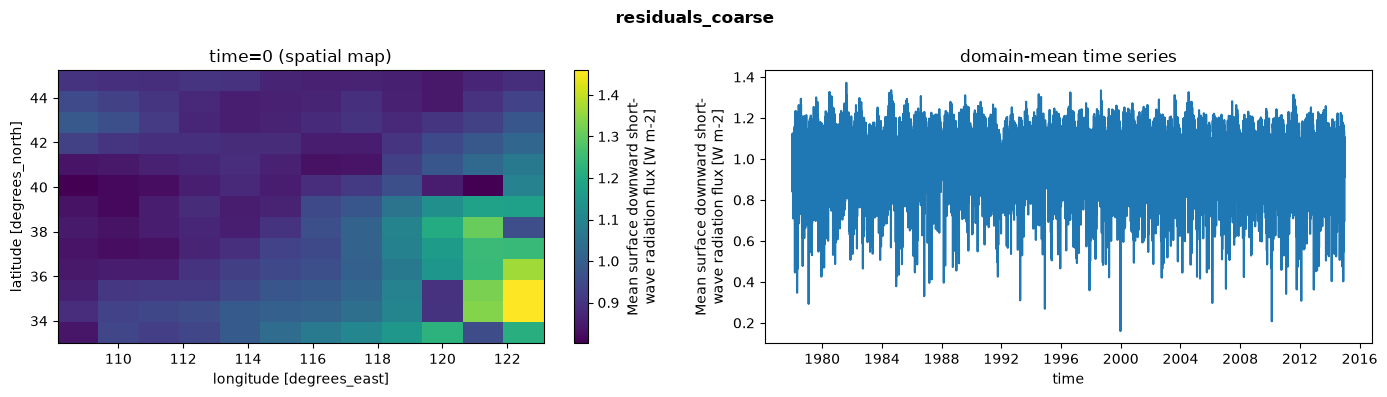

In [53]:
# ── Cell C: coarse spatial residuals (debiased vs coarse climatology) ─────────
if config.variable_config.disaggregation_method == "additive":
    residuals_coarse = debiased_coarse.groupby("time.dayofyear") - obs_coarse_doy_means
elif config.variable_config.disaggregation_method == "multiplicative":
    # Mirror downscale_from_coarse()'s zero-guarded ratio: where the coarse
    # climatology is exactly 0 (dry cells/days) the ratio is forced to 0 rather
    # than producing inf/NaN, then clipped at max_residual (production default 100).
    max_residual = 100
    zero_clim = obs_coarse_doy_means == 0
    safe_clim = obs_coarse_doy_means.where(~zero_clim)  # zeros -> NaN
    residuals_coarse = debiased_coarse.groupby("time.dayofyear") / safe_clim
    zero_clim_on_time = zero_clim.sel(dayofyear=debiased_coarse["time"].dt.dayofyear)
    residuals_coarse = residuals_coarse.where(~zero_clim_on_time, 0.0).clip(max=max_residual)
residuals_coarse = inspect(residuals_coarse, "residuals_coarse")


  residuals_fine
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✗ sporadic_nan_days: FAIL — 13514 time steps have partial NaN coverage
        sporadic_nan_day_count: 13514
        sample_dates: ['1978-01-01', '1978-01-02', '1978-01-03', '1978-01-04', '1978-01-05']
  shape: {'time': 13514, 'lat': 49, 'lon': 61}
  NaN:   0.1382 (13.82%)


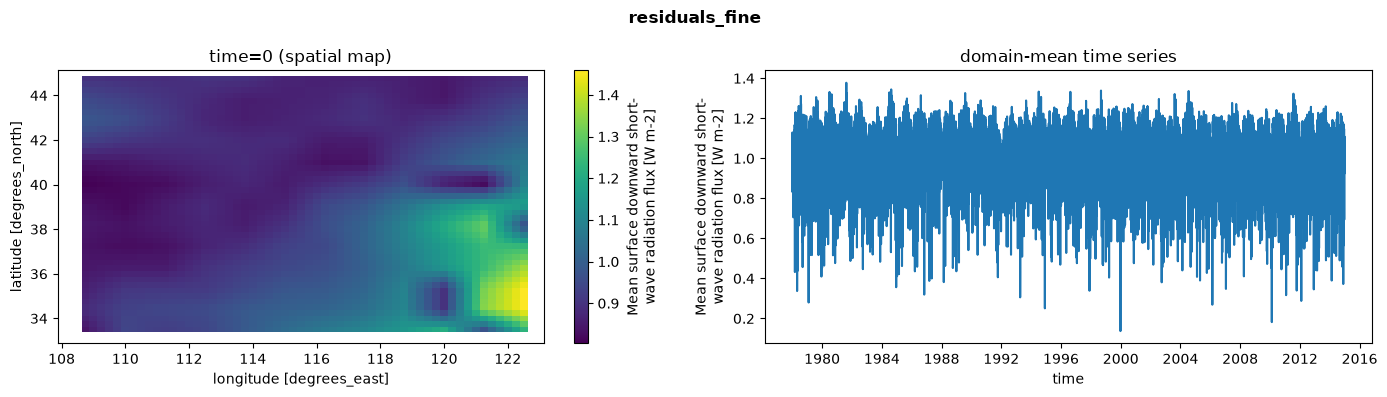

In [54]:
# ── Cell D: interpolate residuals to fine grid ────────────────────────────────
residuals_fine = interpolate_coarse_to_fine_grid(
    da_coarse_to_regrid=residuals_coarse, da_fine_grid=obs_fine_s2
)
residuals_fine = inspect(residuals_fine, "residuals_fine")


  downscaled
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✗ sporadic_nan_days: FAIL — 13514 time steps have partial NaN coverage
        sporadic_nan_day_count: 13514
        sample_dates: ['1978-01-01', '1978-01-02', '1978-01-03', '1978-01-04', '1978-01-05']
  shape: {'time': 13514, 'lat': 49, 'lon': 61}
  NaN:   0.1382 (13.82%)


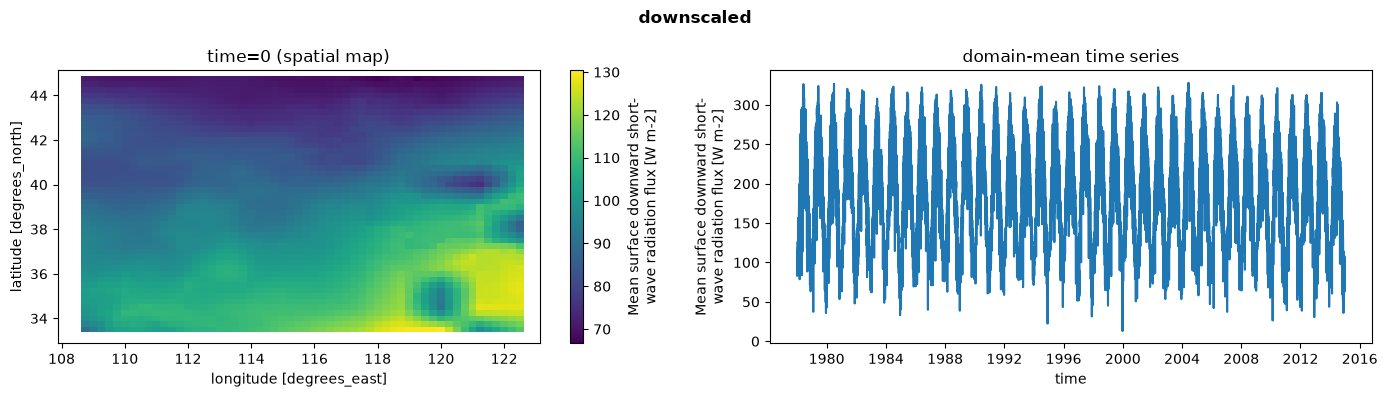

In [55]:
# ── Cell E: reapply fine-grid DOY climatology → final downscaled field ─────────
if config.variable_config.disaggregation_method == "additive":
    downscaled = residuals_fine.groupby("time.dayofyear") + obs_fine_doy_means
elif config.variable_config.disaggregation_method == "multiplicative":
    downscaled = residuals_fine.groupby("time.dayofyear") * obs_fine_doy_means
downscaled = inspect(downscaled, "downscaled")

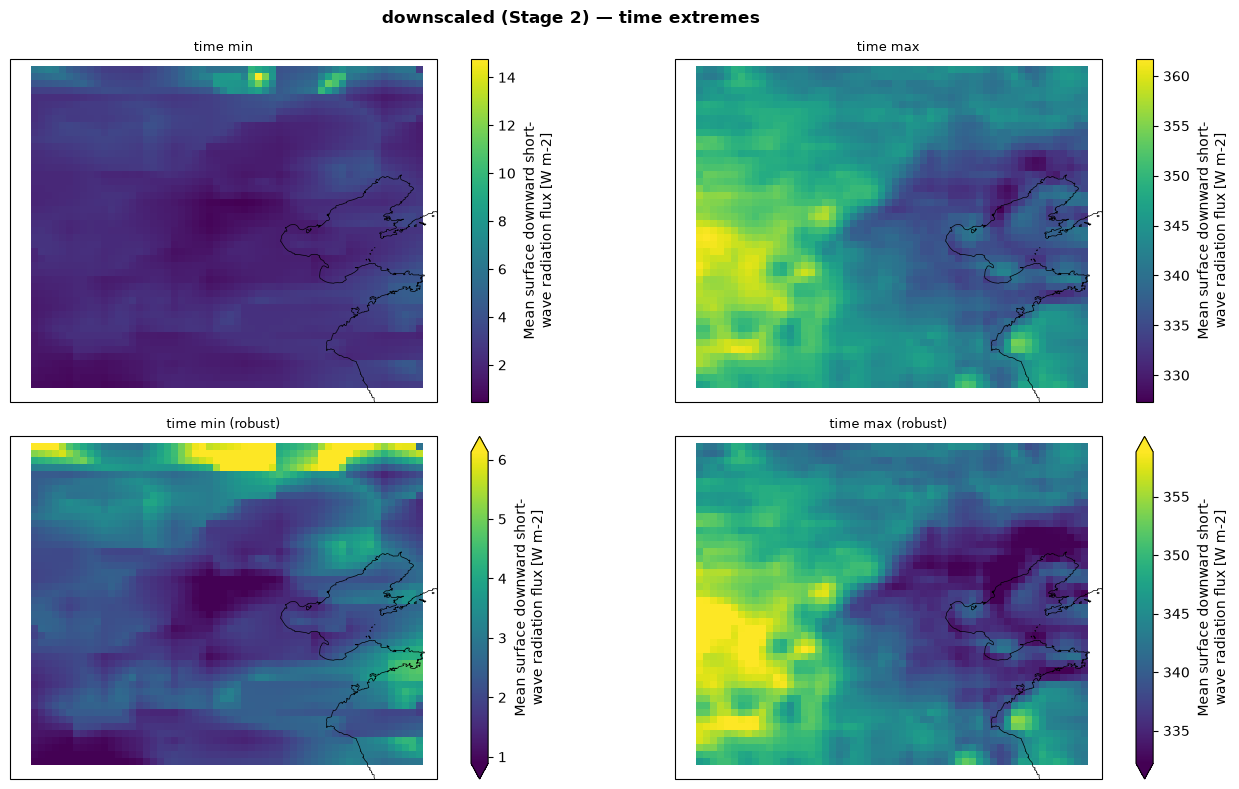


── ERA5-relative exceedance: downscaled (Stage 2) (annual) ──
  ✗ days > ERA5 max: 1025/2989 pixels flagged (34.3%)


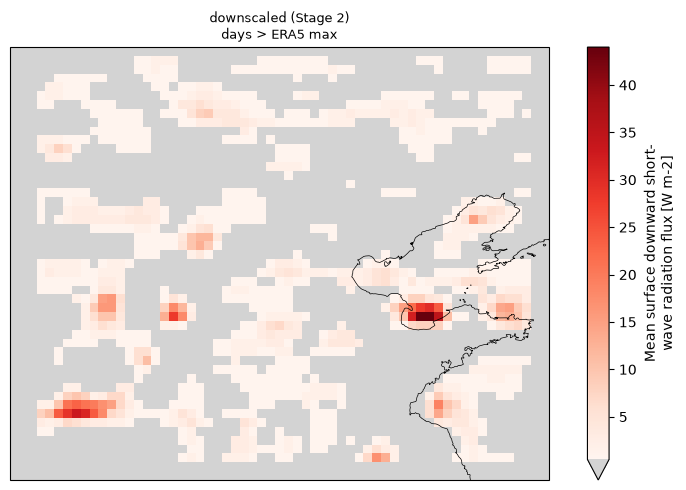

  ✗ days < ERA5 min: 2575/2989 pixels flagged (86.1%)


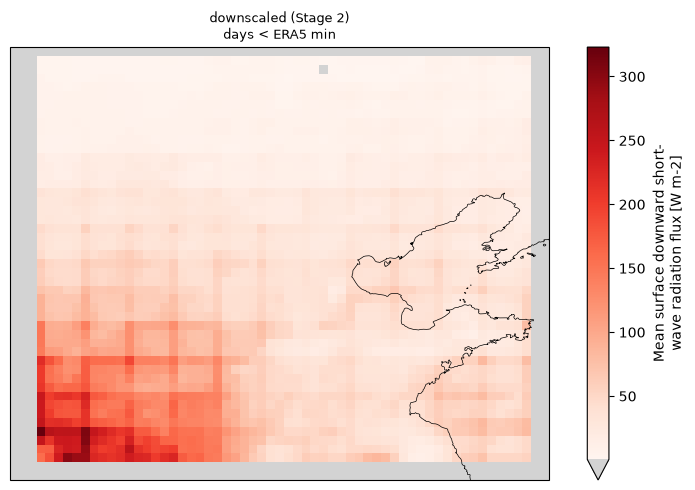

In [56]:
# ── ERA5 exceedance check: downscaled (Stage 2) ───────────────────────────────
# plot_time_extremes: 2×2 grid catches both sign errors (negative pr)
# and extreme outliers that a mean or single-timestep map would hide.
plot_time_extremes(downscaled, "downscaled (Stage 2)")

# Annual check first (fast); switch to period="monthly" to localise
# seasonally-specific exceedances (e.g. summer precipitation extremes).
check_era5_exceedances(downscaled, obs_fine_s2, "downscaled (Stage 2)")
# check_era5_exceedances(downscaled, obs_fine_s2, "downscaled (Stage 2)", period="monthly")

In [57]:
%%time
# ── Cell F: consistency check vs production downscale_from_coarse() ───────────
# Fails loudly if step-by-step result diverges from the production function.
# allow_negative_values=False matches _apply_spatial_downscaling — required for
# Cells A/C above to reproduce it bit-for-bit (esp. multiplicative pr).
ref = downscale_from_coarse(
    da=debiased_coarse,
    obs_coarse=obs_coarse,
    obs_fine=obs_fine_s2,
    method=config.variable_config.disaggregation_method,
    clim_method=config.variable_config.disaggregation_clim_method,
    allow_negative_values=False,
).compute()

match = np.allclose(downscaled.values, ref.values, equal_nan=True)
print(f"Consistency check (Cell F): {'PASS ✓' if match else 'FAIL ✗'}")
assert match, (
    "Step-by-step result diverges from downscale_from_coarse(). "
    "Check residual formulation or interpolation order."
)

Consistency check (Cell F): PASS ✓
CPU times: user 706 ms, sys: 50.2 ms, total: 756 ms
Wall time: 565 ms


In [58]:
# ── Optional: write historical to debug cache for Stage 3 ─────────────────────
# Only needed if you plan to run Stage 3 cells below.  Uncomment and run.
# print("Writing fit_historical to debug cache ...")
# hist_path = pipeline.fit_historical(force=True)
# print(f"  → {hist_path}")


### tasmin special path

If `VARIABLE == "tasmin"`, `fit_historical_tasmin` / `transform_scenario_tasmin`
compute `tasmin = debiased_tasmax − debiased_dtr` from the **debiased-coarse**
tasmax and dtr intermediates instead of debiasing tasmin directly. To debug that
path:

1. Run `fit_historical(force=True)` for **dtr** and **tasmax** with
   `save_intermediate=True` (so the debiased-coarse intermediates are written to
   the debug cache).
2. Then load them and derive tasmin with `derive_tasmin()`, which asserts the
   tasmax and dtr time axes are identical and raises otherwise (issue #363) — so
   a truncated dtr surfaces loudly instead of silently NaN-filling tasmin:
   ```python
   from saidownscale.downscaling_utils import derive_tasmin

   if config.variable == "tasmin":
       debiased_dtr_loc = pipeline.cache.debiased_coarse_historical_loc(
           pipeline._hist_member, variable="dtr"
       )
       debiased_tasmax_loc = pipeline.cache.debiased_coarse_historical_loc(
           pipeline._hist_member, variable="tasmax"
       )
       debiased_dtr = pipeline._open_from_icechunk(debiased_dtr_loc)["dtr"]
       debiased_tasmax = pipeline._open_from_icechunk(debiased_tasmax_loc)["tasmax"]
       debiased_tasmin = derive_tasmin(debiased_tasmax, debiased_dtr).compute()
       debiased_tasmin = inspect(debiased_tasmin, "debiased_tasmin_from_dtr")
       # then run _apply_spatial_downscaling and inspect as above
   ```


## Stage 3 — `transform_scenario`

Cells below run only when `SCENARIO` is set in the config cell. Run
`pipeline.fit_historical(force=True)` (the optional cell at the end of
Stage 2) before executing these cells, so the historical artifact exists in
the debug cache and `_load_scenario_data()` can validate its dependency.


In [59]:
if config.scenario is None:
    raise RuntimeError(
        "SCENARIO is None. Set SCENARIO in the config cell and re-run "
        "from the top before executing Stage 3 cells."
    )

  2026-09-04T04:59:21.836473Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324

  2026-09-04T04:59:21.837680Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324

  2026-09-04T04:59:21.837737Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324




  obs_coarse_s3
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 13, 'lon': 12}
  NaN:   0.0000 (0.00%)


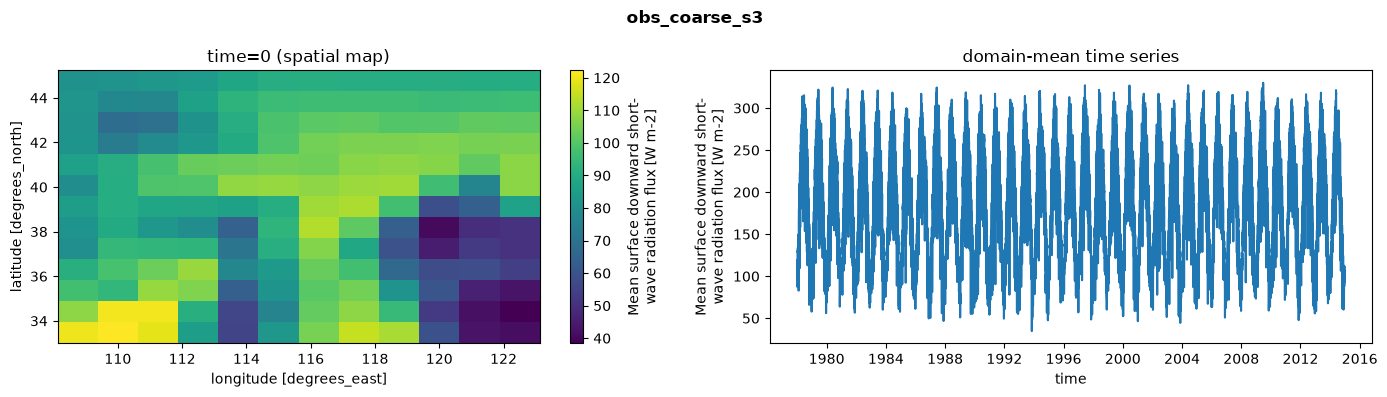


  obs_fine_s3
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 49, 'lon': 61}
  NaN:   0.0000 (0.00%)


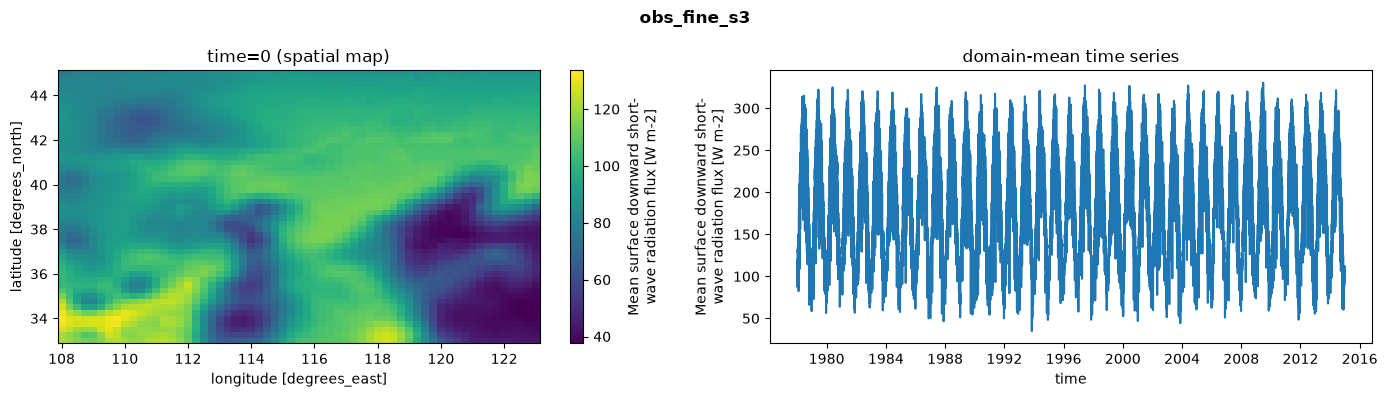


  model_hist_s3
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 13, 'lon': 12}
  NaN:   0.0000 (0.00%)


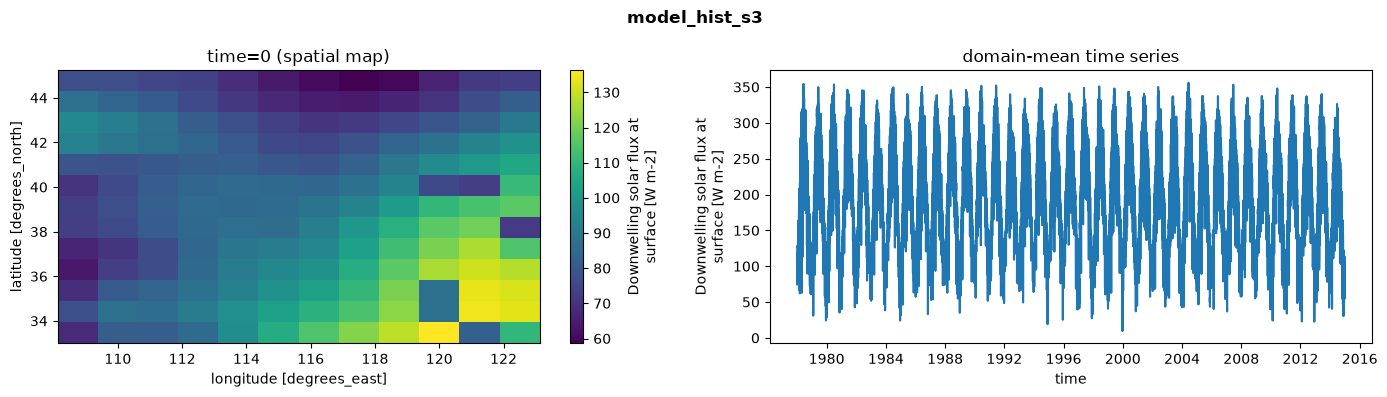


  model_scenario
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 16802, 'lat': 13, 'lon': 12}
  NaN:   0.0000 (0.00%)


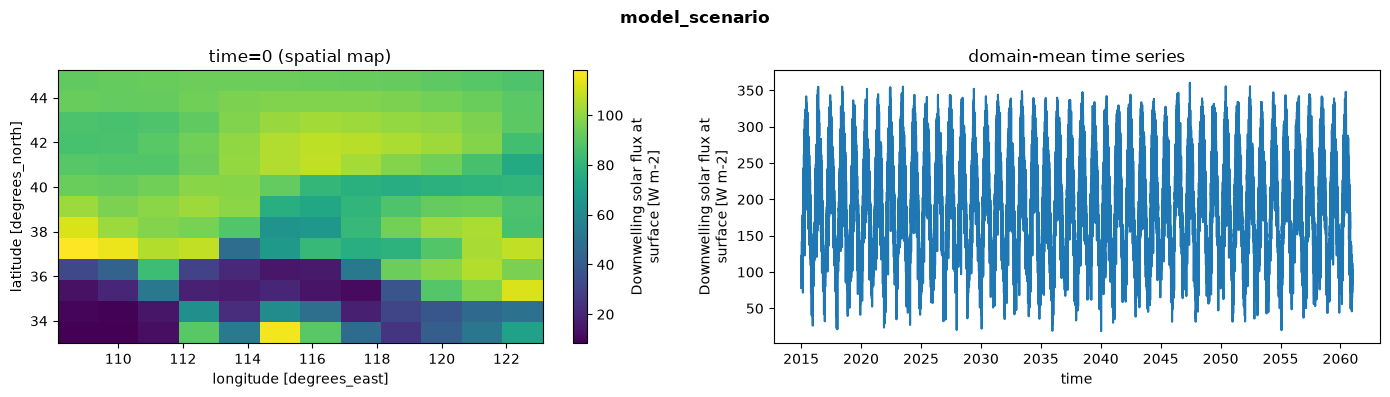

CPU times: user 1min 45s, sys: 44.3 s, total: 2min 30s
Wall time: 34.5 s


In [60]:
%%time
# ── _load_scenario_data ────────────────────────────────────────────────────────
(
    obs_coarse_s3,
    obs_fine_s3,
    model_hist_s3,
    model_scenario,
    ssp_timeseries,
) = pipeline._load_scenario_data()

obs_coarse_s3 = inspect(obs_coarse_s3, "obs_coarse_s3")
obs_fine_s3 = inspect(obs_fine_s3, "obs_fine_s3")
model_hist_s3 = inspect(model_hist_s3, "model_hist_s3")
model_scenario = inspect(model_scenario, "model_scenario")
if ssp_timeseries is not None:
    ssp_timeseries = inspect(ssp_timeseries, "ssp_timeseries")


  scenario_detrended
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 16802, 'lat': 13, 'lon': 12}
  NaN:   0.0000 (0.00%)


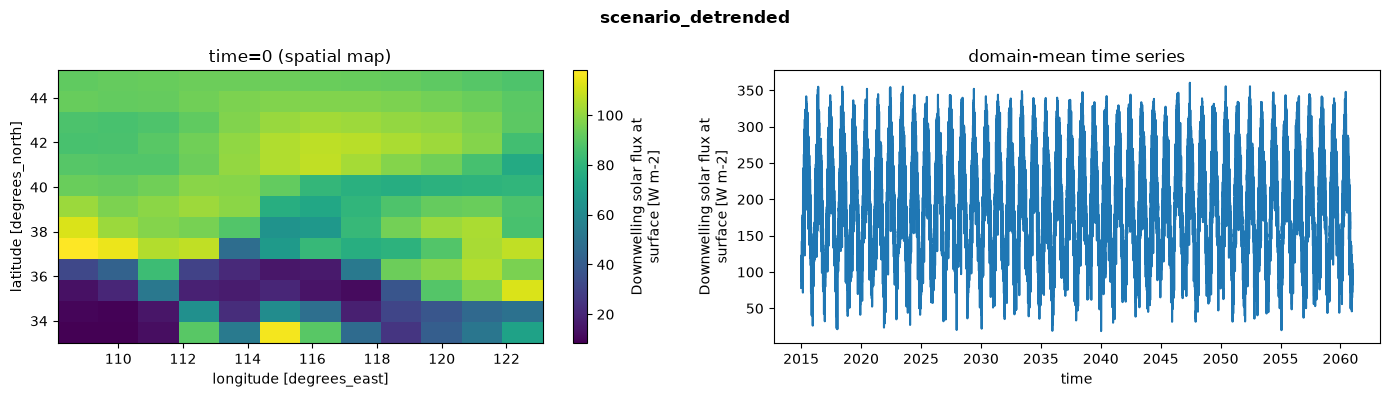

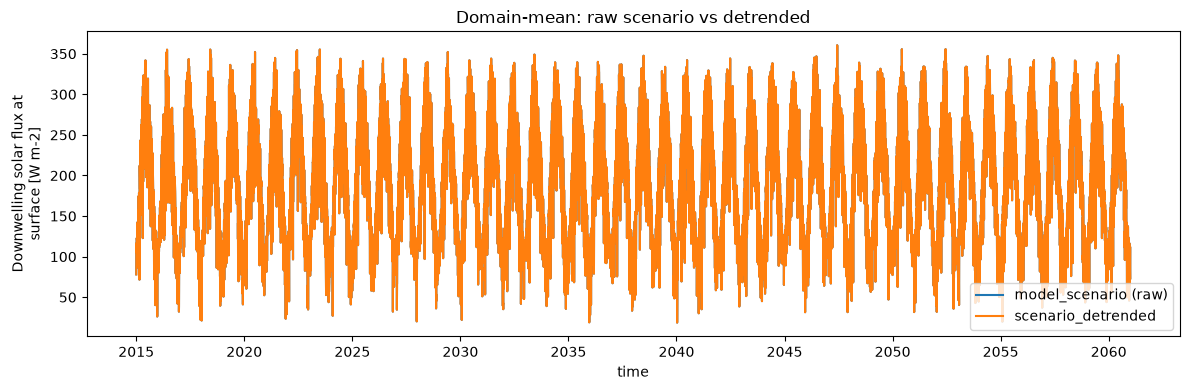

In [61]:
# ── _detrend_scenario ──────────────────────────────────────────────────────────
scenario_detrended, scenario_trend = pipeline._detrend_scenario(
    model_hist_s3, model_scenario, ssp_timeseries
)
scenario_detrended = inspect(scenario_detrended, "scenario_detrended")
if scenario_trend is not None:
    scenario_trend = inspect(scenario_trend, "scenario_trend")

# Visual comparison: detrended vs raw scenario to confirm detrending direction.
fig, ax = plt.subplots(figsize=(12, 4))
model_scenario.mean(["lat", "lon"]).plot(ax=ax, label="model_scenario (raw)")
scenario_detrended.mean(["lat", "lon"]).plot(ax=ax, label="scenario_detrended")
ax.legend()
ax.set_title("Domain-mean: raw scenario vs detrended")
plt.tight_layout()
plt.show()


  scenario_debiased
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 16802, 'lat': 13, 'lon': 12}
  NaN:   0.0000 (0.00%)


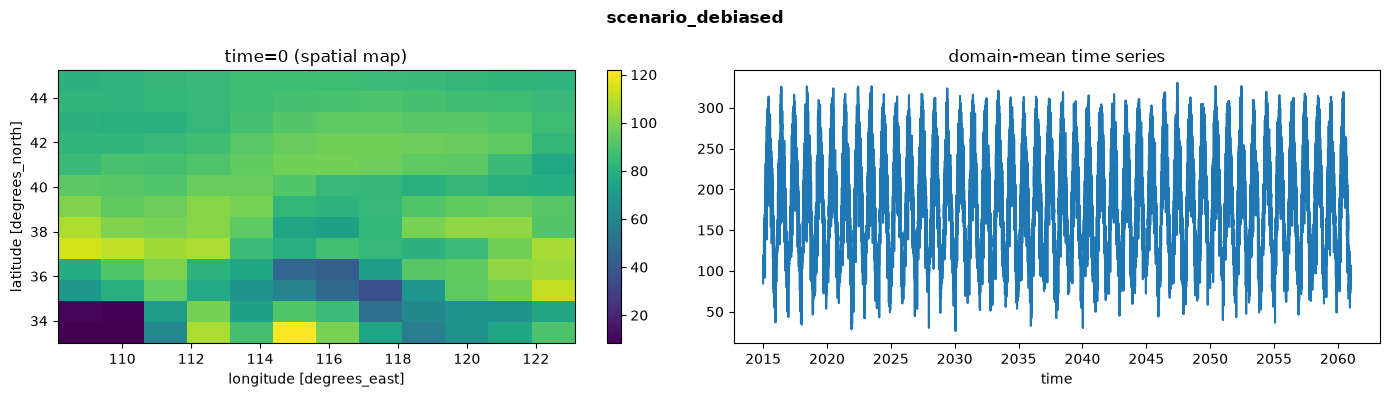

CPU times: user 308 ms, sys: 2.58 s, total: 2.89 s
Wall time: 58.2 s


In [62]:
%%time
# ── _apply_bias_correction_scenario ───────────────────────────────────────────
# model_scenario (pre-detrend) and ssp_timeseries are required for debias_approach
# == "qdm" (used by QDMSD): the qdm branch rebuilds the lead-in pad for the moving
# window over years of cm_future from them. Both are already in memory from
# _load_scenario_data() above. Mirrors the production call in
# BCSDPipeline.transform_scenario.
scenario_debiased = pipeline._apply_bias_correction_scenario(
    obs_coarse_s3, model_hist_s3, scenario_detrended, model_scenario, ssp_timeseries
)
scenario_debiased = inspect(scenario_debiased, "scenario_debiased")

In [63]:
# ── retrend (only if scenario_trend exists) ───────────────────────────────────
if scenario_trend is not None:
    scenario_debiased = retrend(
        scenario_debiased, scenario_trend, config.variable_config.detrend_method
    )
    scenario_debiased = inspect(scenario_debiased, "scenario_debiased_retrended")
else:
    print("No trend to reapply (detrend_data=False for this variable).")

No trend to reapply (detrend_data=False for this variable).


### Scenario spatial disaggregation sub-steps

Cells A and B (obs climatology) were already computed in Stage 2 as
`obs_fine_doy_means` and `obs_coarse_doy_means`. Reuse them here; start from
Cell C.



  scenario_residuals_coarse
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 16802, 'lat': 13, 'lon': 12}
  NaN:   0.0000 (0.00%)


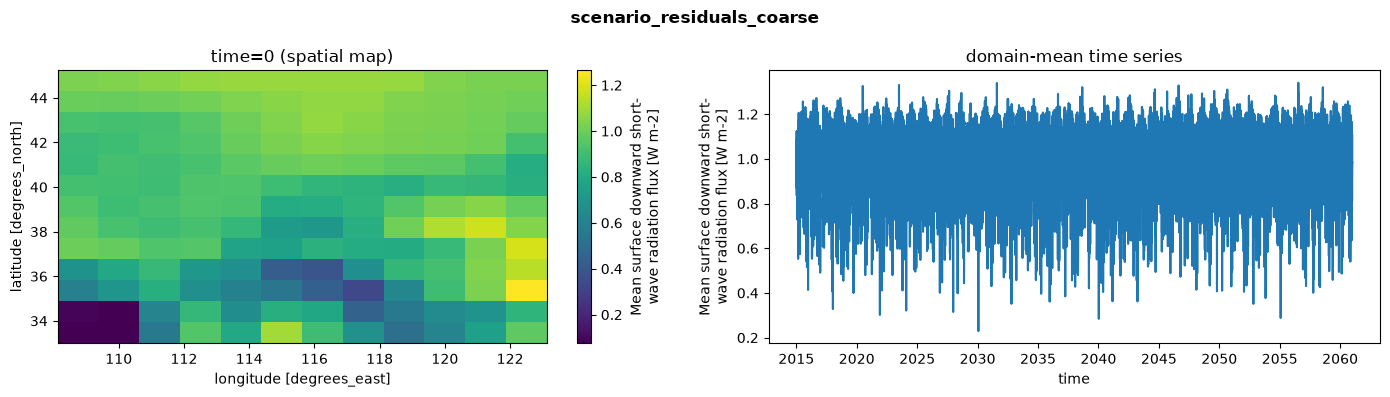

In [64]:
# ── Cell C (scenario): coarse spatial residuals ───────────────────────────────
if config.variable_config.disaggregation_method == "additive":
    scenario_residuals_coarse = scenario_debiased.groupby("time.dayofyear") - obs_coarse_doy_means
elif config.variable_config.disaggregation_method == "multiplicative":
    # Same zero-guarded ratio + clip as Stage 2 Cell C (mirrors downscale_from_coarse()).
    max_residual = 100
    zero_clim = obs_coarse_doy_means == 0
    safe_clim = obs_coarse_doy_means.where(~zero_clim)  # zeros -> NaN
    scenario_residuals_coarse = scenario_debiased.groupby("time.dayofyear") / safe_clim
    zero_clim_on_time = zero_clim.sel(dayofyear=scenario_debiased["time"].dt.dayofyear)
    scenario_residuals_coarse = scenario_residuals_coarse.where(~zero_clim_on_time, 0.0).clip(
        max=max_residual
    )
scenario_residuals_coarse = inspect(scenario_residuals_coarse, "scenario_residuals_coarse")


  scenario_residuals_fine
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✗ sporadic_nan_days: FAIL — 16802 time steps have partial NaN coverage
        sporadic_nan_day_count: 16802
        sample_dates: ['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04', '2015-01-05']
  shape: {'time': 16802, 'lat': 49, 'lon': 61}
  NaN:   0.1382 (13.82%)


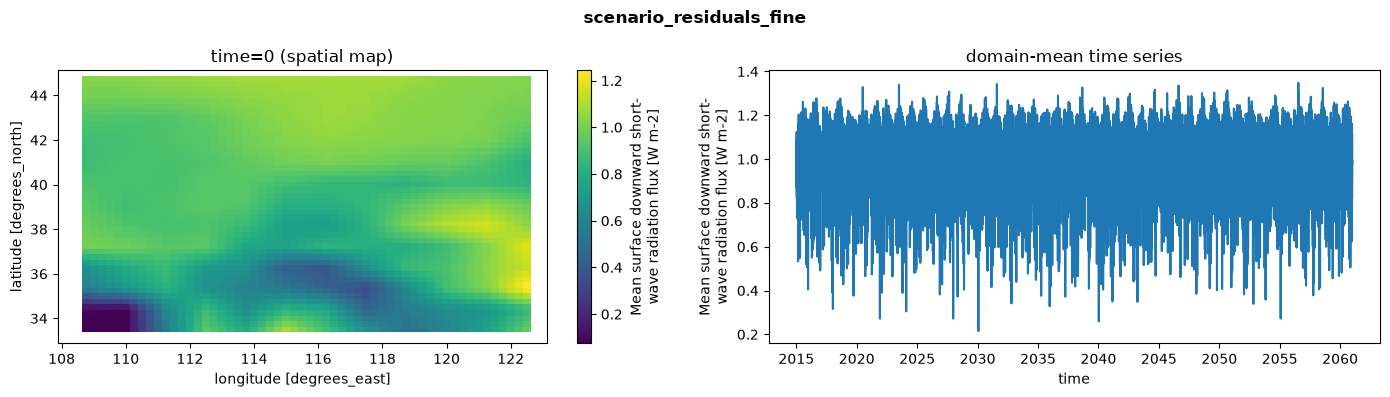

In [65]:
# ── Cell D (scenario): interpolate residuals to fine grid ─────────────────────
# NaN introduced here (interpolation step) vs Cell E (climatology add-back)
# becomes immediately visible as a jump in nan_fraction.
scenario_residuals_fine = interpolate_coarse_to_fine_grid(
    da_coarse_to_regrid=scenario_residuals_coarse, da_fine_grid=obs_fine_s3
)
scenario_residuals_fine = inspect(scenario_residuals_fine, "scenario_residuals_fine")


  scenario_downscaled
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✗ sporadic_nan_days: FAIL — 16802 time steps have partial NaN coverage
        sporadic_nan_day_count: 16802
        sample_dates: ['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04', '2015-01-05']
  shape: {'time': 16802, 'lat': 49, 'lon': 61}
  NaN:   0.1382 (13.82%)


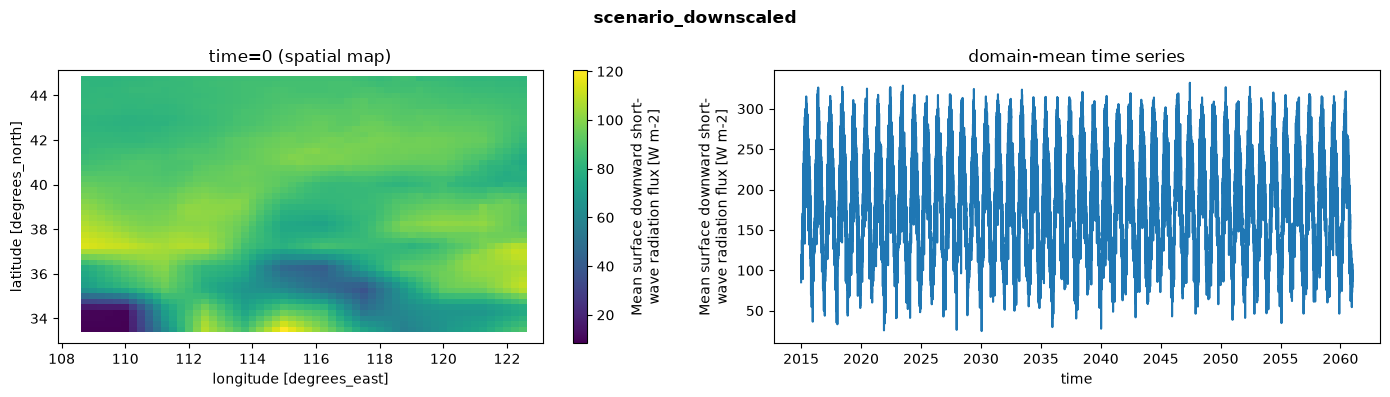

In [66]:
# ── Cell E (scenario): reapply fine-grid DOY climatology ──────────────────────
if config.variable_config.disaggregation_method == "additive":
    scenario_downscaled = scenario_residuals_fine.groupby("time.dayofyear") + obs_fine_doy_means
elif config.variable_config.disaggregation_method == "multiplicative":
    scenario_downscaled = scenario_residuals_fine.groupby("time.dayofyear") * obs_fine_doy_means
scenario_downscaled = inspect(scenario_downscaled, "scenario_downscaled")

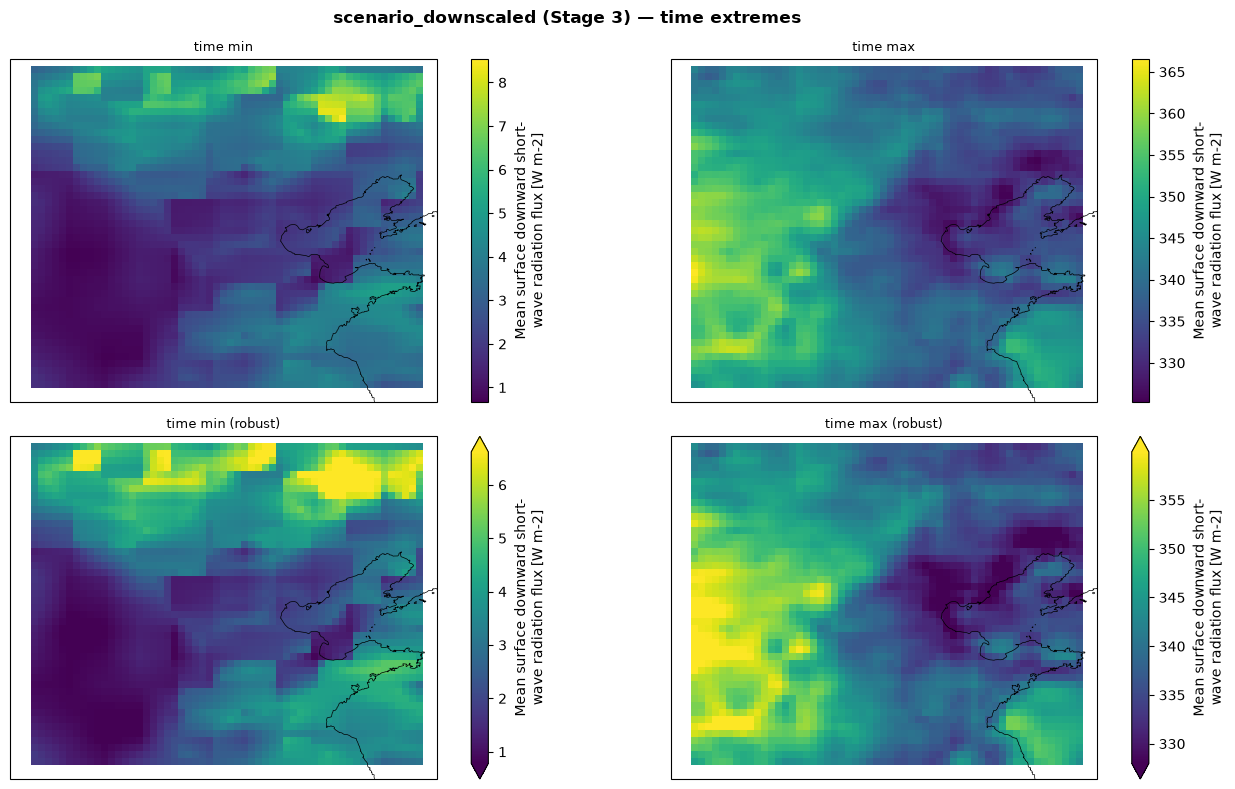


── ERA5-relative exceedance: scenario_downscaled (Stage 3) (annual) ──
  ✗ days > ERA5 max: 723/2989 pixels flagged (24.2%)


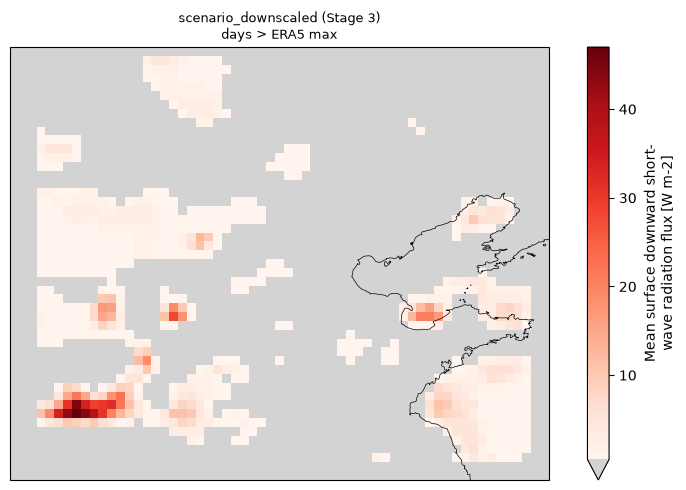

  ✗ days < ERA5 min: 2576/2989 pixels flagged (86.2%)


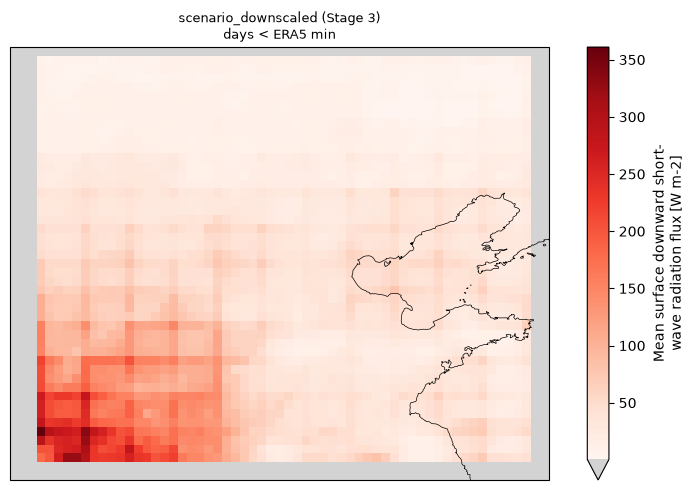

In [67]:
# ── ERA5 exceedance check: scenario_downscaled (Stage 3) ─────────────────────
# obs_fine_s3 is the ERA5 reference — already in memory from _load_scenario_data().
# This cell is the primary regression detector for the all-NaN finding
# documented in pipeline-intermediate-checks-issue-357.ipynb.
plot_time_extremes(scenario_downscaled, "scenario_downscaled (Stage 3)")

check_era5_exceedances(scenario_downscaled, obs_fine_s3, "scenario_downscaled (Stage 3)")
# check_era5_exceedances(scenario_downscaled, obs_fine_s3, "scenario_downscaled (Stage 3)", period="monthly")

In [68]:
%%time
# ── Cell F (scenario): consistency check vs production downscale_from_coarse() ─
# allow_negative_values=False matches _apply_spatial_downscaling (see Stage 2 Cell F).
ref_scenario = downscale_from_coarse(
    da=scenario_debiased,
    obs_coarse=obs_coarse_s3,
    obs_fine=obs_fine_s3,
    method=config.variable_config.disaggregation_method,
    clim_method=config.variable_config.disaggregation_clim_method,
    allow_negative_values=False,
).compute()

match_s3 = np.allclose(scenario_downscaled.values, ref_scenario.values, equal_nan=True)
print(f"Consistency check (Cell F, scenario): {'PASS ✓' if match_s3 else 'FAIL ✗'}")
assert match_s3, (
    "Step-by-step scenario result diverges from downscale_from_coarse(). "
    "Check residual formulation or interpolation order."
)

Consistency check (Cell F, scenario): PASS ✓
CPU times: user 786 ms, sys: 69.4 ms, total: 856 ms
Wall time: 663 ms


In [69]:
# ── Ocean mask (only if apply_ocean_mask is enabled) ─────────────────────────
if options.apply_ocean_mask:
    mask = pipeline._build_ocean_mask(scenario_downscaled)
    land_frac = float(mask.mean())
    print(f"Ocean mask land coverage: {land_frac:.2%}")
    mask.plot(figsize=(8, 4))
    plt.title("Ocean mask (True = land)")
    plt.show()

    scenario_downscaled_masked = scenario_downscaled.where(mask)
    scenario_downscaled_masked = inspect(scenario_downscaled_masked, "scenario_downscaled_masked")
else:
    print("apply_ocean_mask=False — skipping ocean mask step.")

apply_ocean_mask=False — skipping ocean mask step.


In [72]:
pt_lat = 39.9042  # -33.98668063995415
pt_lon = 116.4074  # 18.551467673255665
scenario_downscaled_pt = scenario_downscaled.sel(lat=pt_lat, lon=pt_lon, method="nearest")
gcm_fut_pt = model_scenario.sel(lat=pt_lat, lon=pt_lon, method="nearest")

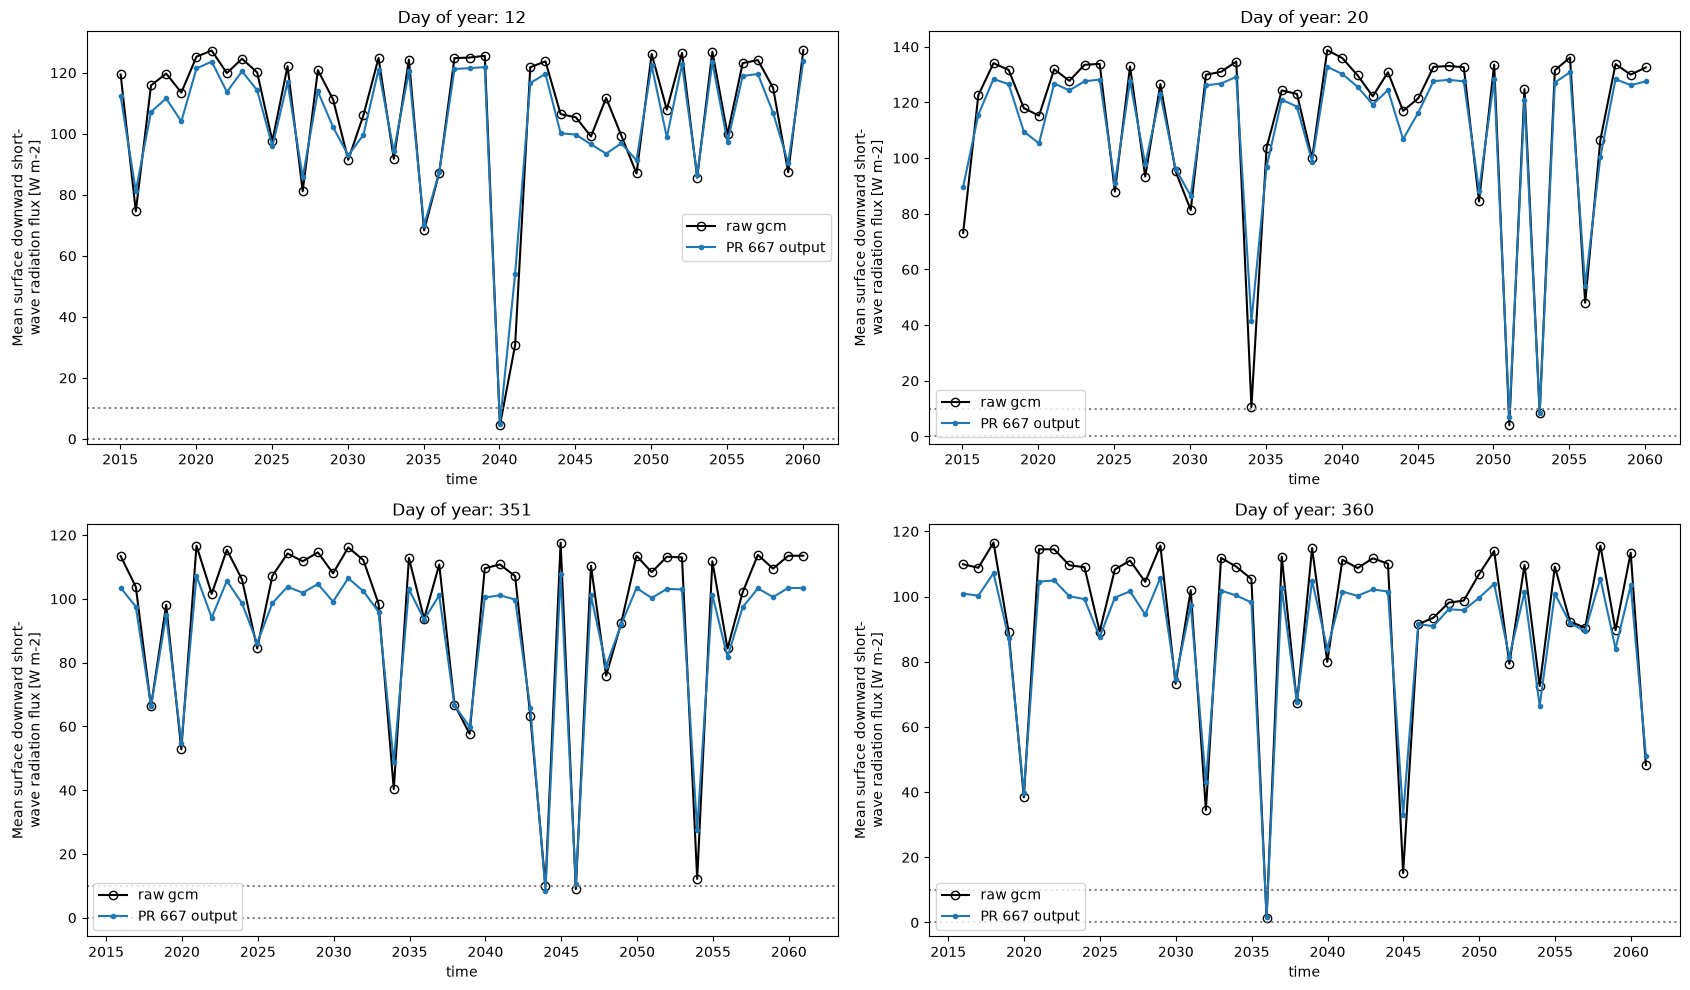

In [76]:
plt.figure(figsize=(17, 10))
doy_list = [12, 20, 351, 360]
for i, doy in enumerate(doy_list):
    plt.subplot(2, 2, i + 1)
    gcm_fut_pt.where(gcm_fut_pt["time.dayofyear"] == doy, drop=True).plot(
        marker="o", fillstyle="none", color="k", label="raw gcm"
    )
    scenario_downscaled_pt.where(scenario_downscaled_pt["time.dayofyear"] == doy, drop=True).plot(
        label="PR 667 output", marker="."
    )

    # print(gcm_fut_pt[:,0,0].where(ds_debiased['time.dayofyear']==doy, drop=True).min().values)
    plt.title("Day of year: " + str(doy))
    plt.axhline(y=0, linestyle=":", color="gray")
    plt.axhline(y=10, linestyle=":", color="gray")
    plt.legend()
plt.tight_layout()